In [9]:
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv('tps_results_full.csv')

# Усреднение по трём прогонам
avg_tps = df.groupby(['buffers', 'mode', 'clients'])['tps'].agg(['mean', 'std']).reset_index()
avg_lat = df.groupby(['buffers', 'mode', 'clients'])['latency_avg'].agg(['mean', 'std']).reset_index()

In [11]:
styles = {
    ('500MB', 'off'): ('blue', 'o', '--'),
    ('500MB', 'on'):  ('blue', 'o', '-'),
    ('1GB',   'off'): ('red',  'o', '--'),
    ('1GB',   'on'):  ('red',  'o', '-'),
}


# **LATENCY_AVG**


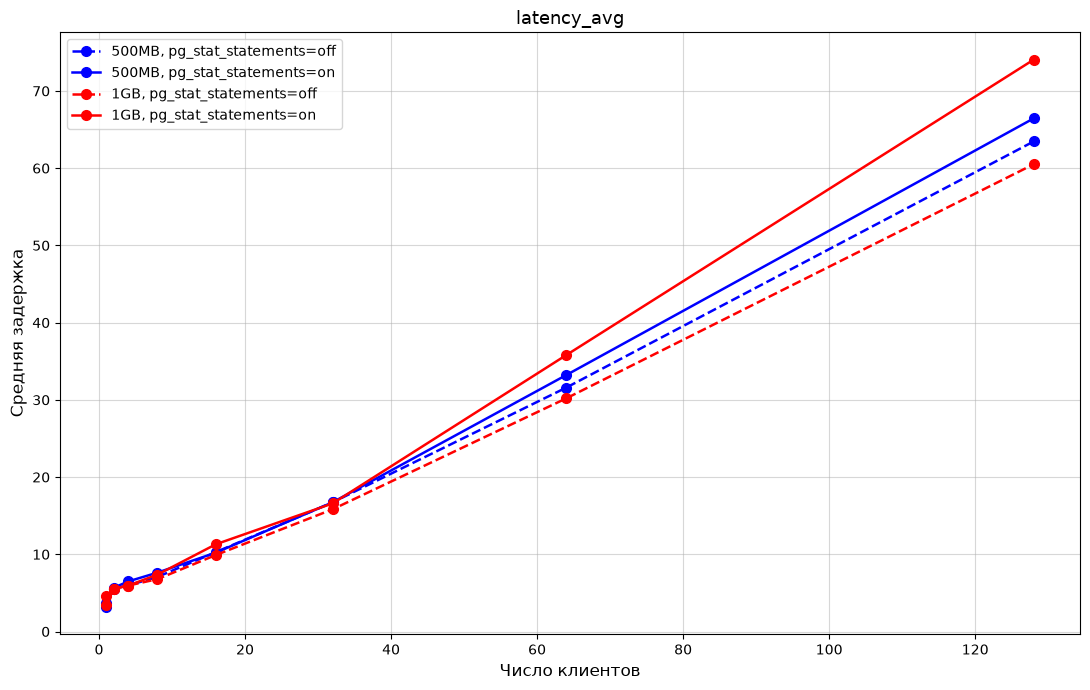

In [12]:
plt.figure(figsize=(11, 7))

for (buf, mode), (color, marker, ls) in styles.items():
    sub = avg_lat[(avg_lat['buffers'] == buf) & (avg_lat['mode'] == mode)].sort_values('clients')
    plt.plot(
        sub['clients'], sub['mean'],
        color=color, marker=marker, linestyle=ls,
        linewidth=1.8, markersize=7,
        label=f'{buf}, pg_stat_statements={mode}'
    )

plt.xlabel('Число клиентов', fontsize=12)
plt.ylabel('Средняя задержка', fontsize=12)
plt.title('latency_avg', fontsize=13)
plt.grid(True, alpha=0.5)
plt.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

# **TPS**

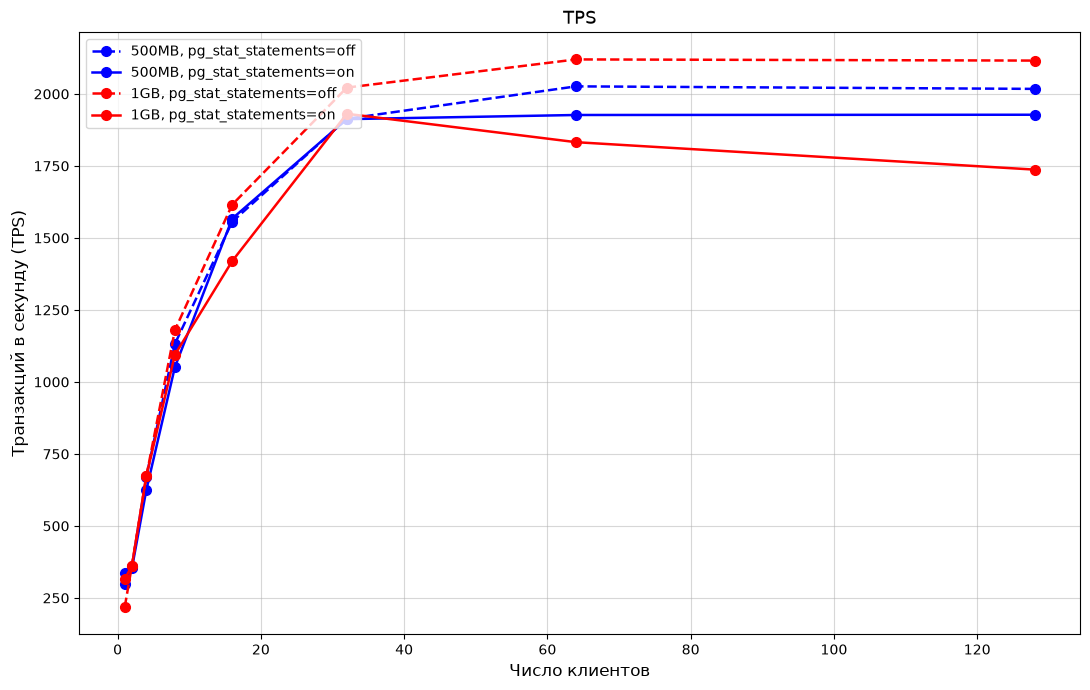

In [13]:
plt.figure(figsize=(11, 7))

for (buf, mode), (color, marker, ls) in styles.items():
    sub = avg_tps[(avg_tps['buffers'] == buf) & (avg_tps['mode'] == mode)].sort_values('clients')
    plt.plot(
        sub['clients'], sub['mean'],
        color=color, marker=marker, linestyle=ls,
        linewidth=1.8, markersize=7,
        label=f'{buf}, pg_stat_statements={mode}'
    )

plt.xlabel('Число клиентов', fontsize=12)
plt.ylabel('Транзакций в секунду (TPS)', fontsize=12)
plt.title('TPS', fontsize=13)
plt.grid(True, alpha=0.5)
plt.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()